In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

normal_path= "/content/drive/MyDrive/paper/CTU13_Normal_Traffic.csv"

attack_path = "/content/drive/MyDrive/paper/CTU13_Attack_Traffic.csv"

In [ ]:
import pandas as pd

normal = pd.read_csv(normal_path)
attack = pd.read_csv(attack_path)

print("Normal shape:", normal.shape)
print("Attack shape:", attack.shape)

normal.head()

Normal shape: (53314, 59)
Attack shape: (38898, 59)


,Unnamed: 0,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,891,0,2,0,348,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
1,1,20835,0,2,0,266,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
2,2,545,0,2,0,442,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
3,3,83892,0,2,0,194,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
4,4,608,0,2,0,480,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
normal['Label'] = 0   # 0 = Normal
attack['Label'] = 1   # 1 = Attack
data = pd.concat([normal, attack], ignore_index=True)

print("Combined shape:", data.shape)
data.head()

Combined shape: (92212, 59)


,Unnamed: 0,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,891,0,2,0,348,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
1,1,20835,0,2,0,266,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
2,2,545,0,2,0,442,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
3,3,83892,0,2,0,194,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
4,4,608,0,2,0,480,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
data = data.reset_index(drop=True)

In [ ]:
print(data.shape)

(92212, 59)


In [ ]:
print(data.columns)

Index(['Unnamed: 0', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Bwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max',
       'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt',
       'SYN Flag Cnt', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio',
       'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
       'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std',
       'Active Max', 'Active Min', 

In [ ]:
data.head()

,Unnamed: 0,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,891,0,2,0,348,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
1,1,20835,0,2,0,266,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
2,2,545,0,2,0,442,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
3,3,83892,0,2,0,194,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0
4,4,608,0,2,0,480,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
print(data.isnull().sum())

Unnamed: 0           0
Flow Duration        0
Tot Fwd Pkts         0
Tot Bwd Pkts         0
TotLen Fwd Pkts      0
TotLen Bwd Pkts      0
Fwd Pkt Len Max      0
Fwd Pkt Len Min      0
Fwd Pkt Len Mean     0
Fwd Pkt Len Std      0
Bwd Pkt Len Max      0
Bwd Pkt Len Min      0
Bwd Pkt Len Mean     0
Bwd Pkt Len Std      0
Flow Byts/s          0
Flow Pkts/s          0
Flow IAT Mean        0
Flow IAT Std         0
Flow IAT Max         0
Flow IAT Min         0
Fwd IAT Tot          0
Fwd IAT Mean         0
Fwd IAT Std          0
Fwd IAT Max          0
Fwd IAT Min          0
Bwd IAT Tot          0
Bwd IAT Mean         0
Bwd IAT Std          0
Bwd IAT Max          0
Bwd IAT Min          0
Bwd PSH Flags        0
Fwd Header Len       0
Bwd Header Len       0
Fwd Pkts/s           0
Bwd Pkts/s           0
Pkt Len Min          0
Pkt Len Max          0
Pkt Len Mean         0
Pkt Len Std          0
Pkt Len Var          0
FIN Flag Cnt         0
SYN Flag Cnt         0
RST Flag Cnt         0
ACK Flag Cn

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92212 entries, 0 to 92211
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         92212 non-null  int64  
 1   Flow Duration      92212 non-null  int64  
 2   Tot Fwd Pkts       92212 non-null  int64  
 3   Tot Bwd Pkts       92212 non-null  int64  
 4   TotLen Fwd Pkts    92212 non-null  int64  
 5   TotLen Bwd Pkts    92212 non-null  int64  
 6   Fwd Pkt Len Max    92212 non-null  int64  
 7   Fwd Pkt Len Min    92212 non-null  int64  
 8   Fwd Pkt Len Mean   92212 non-null  float64
 9   Fwd Pkt Len Std    92212 non-null  float64
 10  Bwd Pkt Len Max    92212 non-null  int64  
 11  Bwd Pkt Len Min    92212 non-null  int64  
 12  Bwd Pkt Len Mean   92212 non-null  float64
 13  Bwd Pkt Len Std    92212 non-null  float64
 14  Flow Byts/s        92212 non-null  float64
 15  Flow Pkts/s        92212 non-null  float64
 16  Flow IAT Mean      922

In [ ]:

data = data.drop(columns=['Unnamed: 0'])


In [ ]:

numeric_cols = [
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
    'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
    'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s'
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [ ]:
data['TotPkts'] = data['Tot Fwd Pkts'] + data['Tot Bwd Pkts']


In [ ]:
data['TotBytes'] = data['TotLen Fwd Pkts'] + data['TotLen Bwd Pkts']

In [ ]:
data['AvgPktLen'] = data['TotBytes'] / (data['TotPkts'] + 1e-5)

In [ ]:
data['ClientBehaviorScore'] = (
    data['TotPkts'] +
    data['TotBytes'] +
    data['Flow Duration']
) / 3

data['CommPattern'] = (
    data['Flow IAT Mean'] +
    data['Flow IAT Std']
) / 2


print(data[['ClientBehaviorScore','CommPattern']].head())

   ClientBehaviorScore  CommPattern
0           413.666667        445.5
1          7034.333333      10417.5
2           329.666667        272.5
3         28029.333333      41946.0
4           363.333333        304.0


In [ ]:
print(data.shape)

(92212, 63)


In [ ]:
data['DNSQueryConsistency'] = (
    data['Flow IAT Std'] / (data['Flow IAT Mean'] + 1e-5)
)

In [ ]:
data['QueryRate'] = data['Flow Pkts/s']

In [ ]:
feature_cols = [
    'ClientBehaviorScore',
    'CommPattern',
    'DNSQueryConsistency',
    'QueryRate',
    'TotPkts',
    'TotBytes',
    'AvgPktLen',
    'Flow Duration'
]

X = data[feature_cols]
y = data['Label']

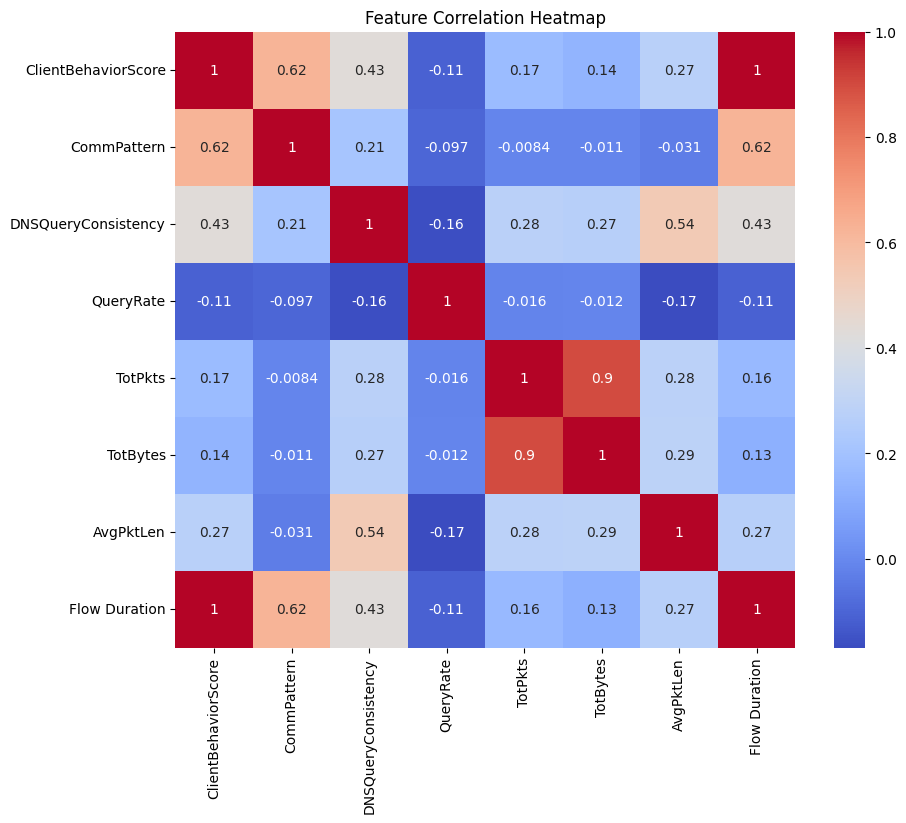

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data[feature_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [ ]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report

val_pred = rf.predict(X_val)
print("Random Forest Validation")
print(classification_report(y_val, val_pred))

Random Forest Validation
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7931
           1       0.97      0.96      0.97      5901

    accuracy                           0.97     13832
   macro avg       0.97      0.97      0.97     13832
weighted avg       0.97      0.97      0.97     13832



In [ ]:
test_pred = rf.predict(X_test)
print("Random Forest Test")
print(classification_report(y_test, test_pred))

Random Forest Test
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8049
           1       0.97      0.97      0.97      5783

    accuracy                           0.97     13832
   macro avg       0.97      0.97      0.97     13832
weighted avg       0.97      0.97      0.97     13832



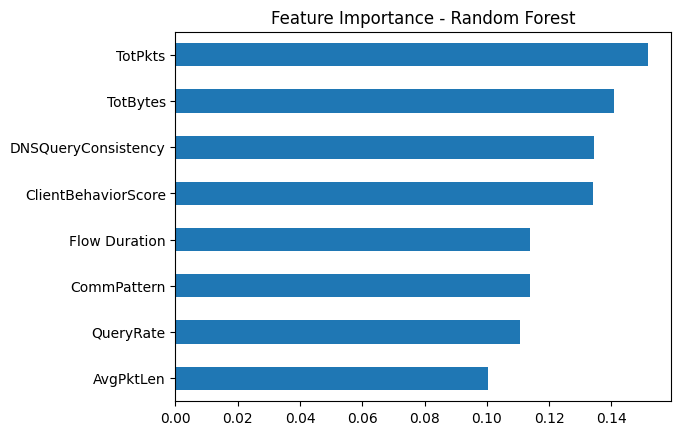

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()

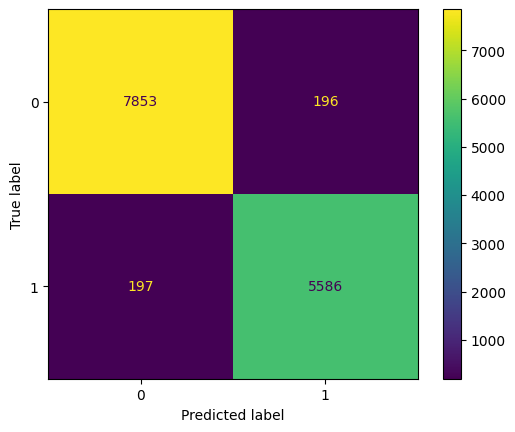

In [ ]:

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [ ]:

val_pred = lr.predict(X_val_scaled)
print("Logistic Regression Validation")
print(classification_report(y_val, val_pred))


Logistic Regression Validation
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      7931
           1       0.75      0.69      0.72      5901

    accuracy                           0.77     13832
   macro avg       0.77      0.76      0.76     13832
weighted avg       0.77      0.77      0.77     13832



In [ ]:
test_pred = lr.predict(X_test_scaled)
print("Logistic Regression Test")
print(classification_report(y_test, test_pred))

Logistic Regression Test
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      8049
           1       0.73      0.69      0.71      5783

    accuracy                           0.77     13832
   macro avg       0.76      0.76      0.76     13832
weighted avg       0.76      0.77      0.77     13832



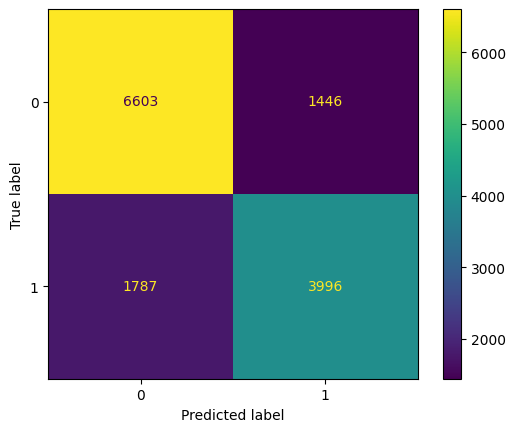

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.show()

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)



SVC()

In [ ]:
val_pred = svm.predict(X_val_scaled)
print("SVM Validation")
print(classification_report(y_val, val_pred))


SVM Validation
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      7931
           1       0.82      0.89      0.86      5901

    accuracy                           0.87     13832
   macro avg       0.87      0.87      0.87     13832
weighted avg       0.88      0.87      0.87     13832



In [ ]:

test_pred = svm.predict(X_test_scaled)
print("SVM Test")
print(classification_report(y_test, test_pred))

SVM Test
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      8049
           1       0.81      0.89      0.85      5783

    accuracy                           0.87     13832
   macro avg       0.87      0.87      0.87     13832
weighted avg       0.87      0.87      0.87     13832



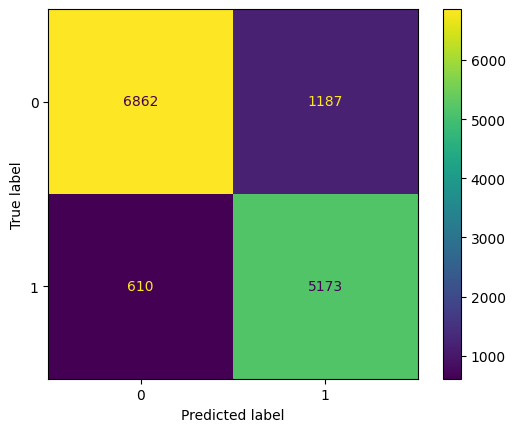

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(svm, X_test_scaled, y_test)
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=30)
gb.fit(X_train, y_train)



GradientBoostingClassifier(random_state=30)

In [ ]:
val_pred = gb.predict(X_val)
print("Gradient Boosting Validation")
print(classification_report(y_val, val_pred))



Gradient Boosting Validation
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7931
           1       0.94      0.93      0.93      5901

    accuracy                           0.94     13832
   macro avg       0.94      0.94      0.94     13832
weighted avg       0.94      0.94      0.94     13832



In [ ]:
test_pred = gb.predict(X_test)
print("Gradient Boosting Test")
print(classification_report(y_test, test_pred))



Gradient Boosting Test
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8049
           1       0.94      0.93      0.93      5783

    accuracy                           0.94     13832
   macro avg       0.94      0.94      0.94     13832
weighted avg       0.94      0.94      0.94     13832



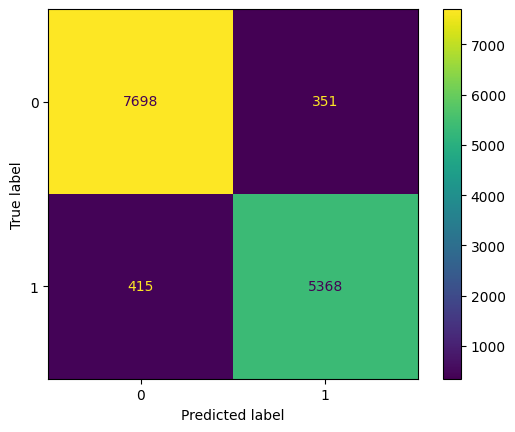

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
val_pred = dt.predict(X_val)
print("Decision Tree Validation")
print(classification_report(y_val, val_pred))



Decision Tree Validation
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7931
           1       0.96      0.96      0.96      5901

    accuracy                           0.96     13832
   macro avg       0.96      0.96      0.96     13832
weighted avg       0.96      0.96      0.96     13832



In [ ]:
test_pred = dt.predict(X_test)
print("Decision Tree Test")
print(classification_report(y_test, test_pred))

Decision Tree Test
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      8049
           1       0.96      0.96      0.96      5783

    accuracy                           0.97     13832
   macro avg       0.97      0.97      0.97     13832
weighted avg       0.97      0.97      0.97     13832



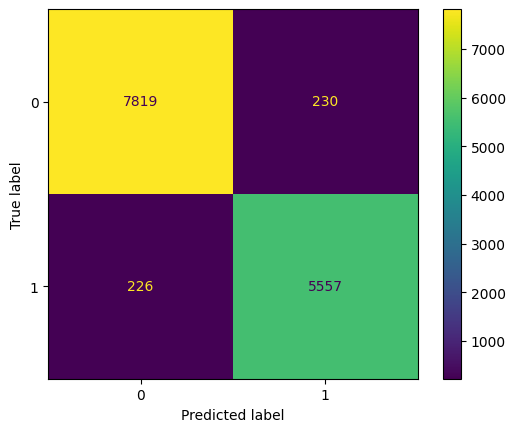

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)



KNeighborsClassifier()

In [ ]:
val_pred = knn.predict(X_val_scaled)
print("KNN Validation")
print(classification_report(y_val, val_pred))



KNN Validation
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      7931
           1       0.96      0.95      0.95      5901

    accuracy                           0.96     13832
   macro avg       0.96      0.96      0.96     13832
weighted avg       0.96      0.96      0.96     13832



In [ ]:
test_pred = knn.predict(X_test_scaled)
print("KNN Test")
print(classification_report(y_test, test_pred))



KNN Test
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      8049
           1       0.96      0.95      0.95      5783

    accuracy                           0.96     13832
   macro avg       0.96      0.96      0.96     13832
weighted avg       0.96      0.96      0.96     13832



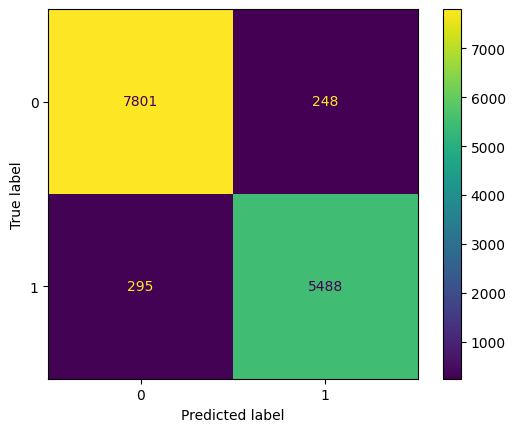

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.show()

In [ ]:
from sklearn.metrics import f1_score

models = {
    "RandomForest": rf.predict(X_test),
    "GradientBoosting": gb.predict(X_test),
    "LogisticRegression": lr.predict(X_test_scaled),
    "SVM": svm.predict(X_test_scaled),
    "KNN": knn.predict(X_test_scaled),
    "DecisionTree": dt.predict(X_test)
}

for name, pred in models.items():
    print(name, "F1:", f1_score(y_test, pred))

RandomForest F1: 0.9660181582360571
GradientBoosting F1: 0.9334028864545296
LogisticRegression F1: 0.7119821826280623
SVM F1: 0.8520135057234621
KNN F1: 0.9528604913620974
DecisionTree F1: 0.9605877268798617


In [ ]:
from sklearn.metrics import classification_report

print("Random Forest")
print(classification_report(y_test, rf.predict(X_test)))

print("Gradient Boosting")
print(classification_report(y_test, gb.predict(X_test)))

print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test_scaled)))

print("SVM")
print(classification_report(y_test, svm.predict(X_test_scaled)))

print("KNN")
print(classification_report(y_test, knn.predict(X_test_scaled)))

print("Decision Tree")
print(classification_report(y_test, dt.predict(X_test)))

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8049
           1       0.97      0.97      0.97      5783

    accuracy                           0.97     13832
   macro avg       0.97      0.97      0.97     13832
weighted avg       0.97      0.97      0.97     13832

Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8049
           1       0.94      0.93      0.93      5783

    accuracy                           0.94     13832
   macro avg       0.94      0.94      0.94     13832
weighted avg       0.94      0.94      0.94     13832

Logistic Regression
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      8049
           1       0.73      0.69      0.71      5783

    accuracy                           0.77     13832
   macro avg       0.76      0.76      0.76     13832
weighted avg       0.7

In [ ]:
from sklearn.metrics import classification_report

print("Random Forest")
print(classification_report(y_val, rf.predict(X_val)))

print("Gradient Boosting")
print(classification_report(y_val, gb.predict(X_val)))

print("Logistic Regression")
print(classification_report(y_val, lr.predict(X_val_scaled)))

print("SVM")
print(classification_report(y_val, svm.predict(X_val_scaled)))

print("KNN")
print(classification_report(y_val, knn.predict(X_val_scaled)))

print("Decision Tree")
print(classification_report(y_val, dt.predict(X_val)))

Random Forest
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7931
           1       0.97      0.96      0.97      5901

    accuracy                           0.97     13832
   macro avg       0.97      0.97      0.97     13832
weighted avg       0.97      0.97      0.97     13832

Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7931
           1       0.94      0.93      0.93      5901

    accuracy                           0.94     13832
   macro avg       0.94      0.94      0.94     13832
weighted avg       0.94      0.94      0.94     13832

Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      7931
           1       0.75      0.69      0.72      5901

    accuracy                           0.77     13832
   macro avg       0.77      0.76      0.76     13832
weighted avg       0.7

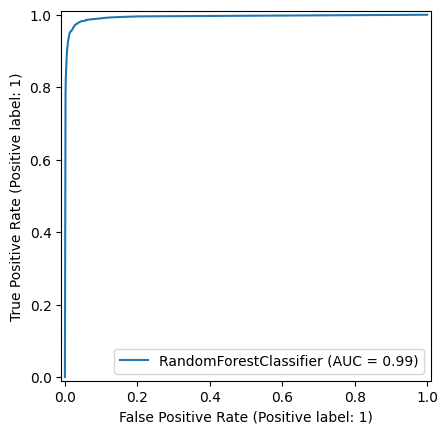

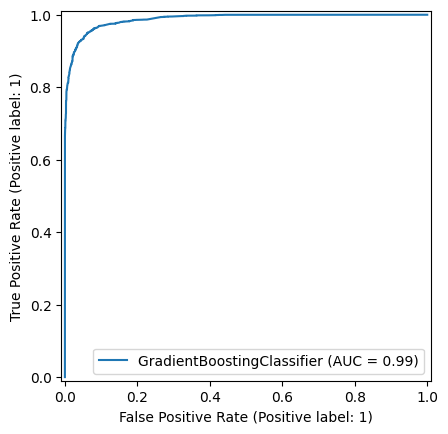

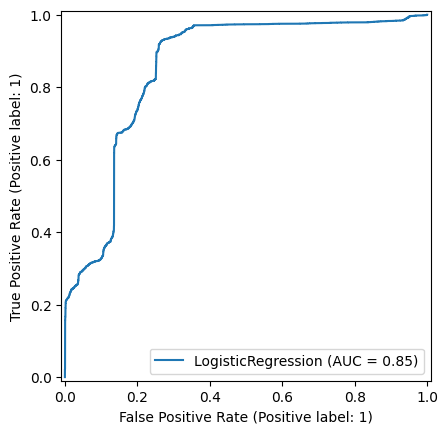

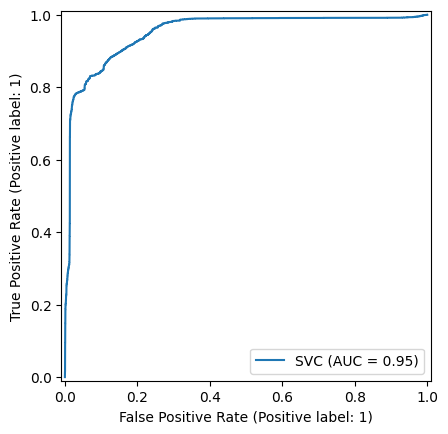

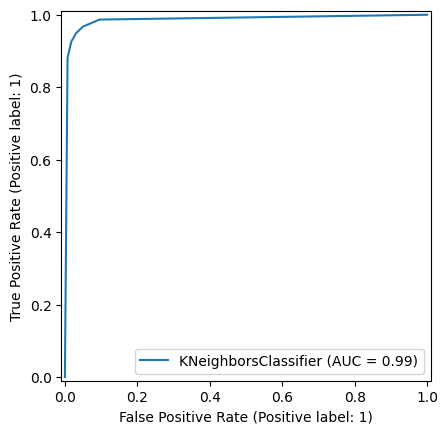

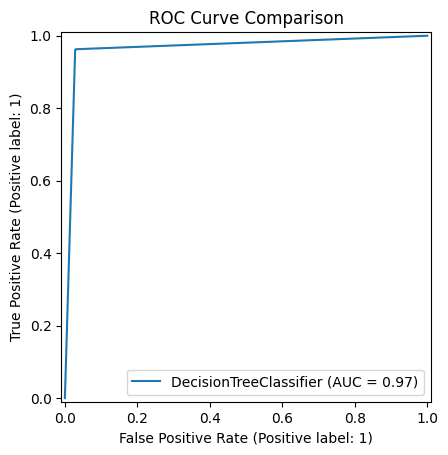

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf, X_test, y_test)
RocCurveDisplay.from_estimator(gb, X_test, y_test)
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)
RocCurveDisplay.from_estimator(svm, X_test_scaled, y_test)
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)
RocCurveDisplay.from_estimator(dt, X_test, y_test)

plt.title("ROC Curve Comparison")
plt.show()